In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding
import deep_sdf.workspace as ws
from sdf_utils import sap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [2]:
# 1. Load the latent vectors from your trained model
experiment_dir = "/home/jakaria/INR/Deep3DComp/examples/torus/sixteen_variable_z" 
checkpoint = "latest" 

# Load latent vectors
latent_vectors = ws.load_latent_vectors(experiment_dir, checkpoint)
X = latent_vectors.cpu().numpy()

print(f"Loaded latent vectors with shape: {X.shape}")

Loaded latent vectors with shape: (369, 16)


In [ ]:
# 2. Load the filenames of the meshes
with open(os.path.join(experiment_dir, "specs.json"), "r") as f:
    import json
    specs = json.load(f)
# Load all labels from the centralized label.pt file
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]
labels_path = os.path.join(data_source, "labels.pt")

# Load the split file to get filenames
with open(train_split_file, "r") as f:
    valid_filenames = json.load(f)

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    print(f"All labels: {all_labels}")
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        print(f"Base name: {base_name}")
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["has_bump"] = int(label[0].item())  # bump info at index 0
            params["scale"] = float(label[2].item())   # scale info at index 2
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["has_bump"] = 0
            params["scale"] = 0.0
        
        mesh_params.append(params)

Loading labels from /home/jakaria/torus_two_models_data/torus_two/sdf_data/SdfSamples/obj_files/labels.pt
All labels: {'torus_bump_000': array([-1.        ,  0.38383838]), 'torus_bump_001': array([-0.99599198,  0.46464646]), 'torus_bump_002': array([-0.99198397,  0.77777778]), 'torus_bump_003': array([-0.98797595,  0.38383838]), 'torus_bump_004': array([-0.98396794,  0.82828283]), 'torus_bump_005': array([-0.97995992,  0.83838384]), 'torus_bump_006': array([-0.9759519 ,  0.94949495]), 'torus_bump_007': array([-0.97194389,  0.42424242]), 'torus_bump_008': array([-0.96793587,  0.12121212]), 'torus_bump_009': array([-0.96392786,  1.        ]), 'torus_bump_010': array([-0.95991984,  0.72727273]), 'torus_bump_011': array([-0.95591182,  0.23232323]), 'torus_bump_012': array([-0.95190381,  0.13131313]), 'torus_bump_013': array([-0.94789579,  0.55555556]), 'torus_bump_014': array([-0.94388778,  0.82828283]), 'torus_bump_015': array([-0.93987976,  0.22222222]), 'torus_bump_016': array([-0.93587

In [ ]:
# Extract parameters for visualization
has_bump = np.array([p.get("has_bump", 0) for p in mesh_params])
scales = np.array([p.get("scale", 0.0) for p in mesh_params])

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_bump, scales))
factor_names = ["bump", "scale"]

In [11]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [ ]:

# 3.1. PCA
print("Applying PCA...")
pca = PCA(n_components=4)
Y_pca = pca.fit_transform(X)
results["PCA"] = Y_pca
transformed_latents["PCA"] = Y_pca
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# check if the scale is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA

best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions (2 to 4)
for n_neighbors in range(300, 320, 10):  # e.g., 5, 10, 15, 20, 25 neighbors
    for n_components in [2]:
        try:
            # Apply HLLE with current parameter set
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            # Apply ICA to the HLLE result
            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            # Compute the correlation for each latent variable with scales
            correlations = []
            for comp in range(n_components):
                corr = np.corrcoef(Y_hlle_ica[:, comp], has_bump)[0, 1]
                correlations.append(corr)
            print(correlations)
            # Find the index of the component with the highest absolute correlation
            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]
            
            # Print the results
            print(f"n_neighbors: {n_neighbors}, n_components: {n_components}, "
                  f"best component correlation: {best_component_corr:.4f}")

            # Update if this parameter set shows a higher absolute correlation than previous sets
            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)
                
        except Exception as e:
            print(f"Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}")

if best_Y_hlle_ica is not None:
    print("\nBest parameter set:")
    print(f"n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}")
    results["HLLE+ICA"] = best_Y_hlle_ica
    transformed_latents["HLLE+ICA"] = best_Y_hlle_ica
else:
    print("No valid HLLE+ICA transformation found.")

Applying PCA...
PCA explained variance ratio: 0.3129
Correlation between distance from origin and scale: -0.0628
[0.9246336691793327, 0.07212083847187409]
n_neighbors: 300, n_components: 2, best component correlation: 0.9246
[-0.05529929753395482, 0.9249144437740663]
n_neighbors: 310, n_components: 2, best component correlation: 0.9249

Best parameter set:
n_neighbors: 310, n_components: 2, best component: 1 best correlation: 0.9249


In [ ]:
# 3.3. NMF
print("Applying NMF...")
# NMF requires non-negative values
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

# Loop over latent dimensions 2, 3, and 4
for n_components in [2, 3, 4]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        # W is the latent representation: shape (num_samples, n_components)
        W = nmf.fit_transform(X_offset)
        
        # Compute the Pearson correlation for each latent component with the scale
        correlations = []
        for comp in range(n_components):
            corr = np.corrcoef(W[:, comp], has_bump)[0, 1]
            correlations.append(corr)
        
        # Identify the best component correlation (by absolute value)
        best_component_corr = max(correlations, key=abs)
        print(f"n_components: {n_components}, best component correlation: {best_component_corr:.4f}")

        # Update if this parameter set shows a higher absolute correlation than previous sets
        if best_corr_nmf is None or abs(best_component_corr) > best_corr_nmf:
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components
            
    except Exception as e:
        print(f"Failed for n_components: {n_components} due to: {e}")

if best_W_nmf is not None:
    print("\nBest NMF parameter set:")
    print(f"n_components: {best_nmf_params}, best correlation: {best_corr_nmf:.4f}")
    results["NMF"] = best_W_nmf
    transformed_latents["NMF"] = best_W_nmf
else:
    print("No valid NMF transformation found.")

Applying NMF...
n_components: 2, best component correlation: 0.8979
n_components: 3, best component correlation: -0.8870
n_components: 4, best component correlation: 0.8181

Best NMF parameter set:
n_components: 2, best correlation: 0.8979


In [8]:
# 3.4. Factor Analysis
print("Applying Factor Analysis...")
fa = FactorAnalysis(n_components=2, random_state=42)
Y_fa = fa.fit_transform(X)
results["FA"] = Y_fa
transformed_latents["FA"] = Y_fa

# check if the scale is encoded as distance from the origin
center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_fa = distances
distances_all.append(distances)

Applying Factor Analysis...
Correlation between distance from origin and scale: -0.1161


In [9]:
# only ica
# 3.5. ICA
print("Applying ICA...")
ica = FastICA(n_components=2, random_state=42)
Y_ica = ica.fit_transform(X)
results["ICA"] = Y_ica
transformed_latents["ICA"] = Y_ica

# check if the scale is encoded as distance from the origin
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_ica = distances
distances_all.append(distances)

Applying ICA...
Correlation between distance from origin and scale: -0.0722


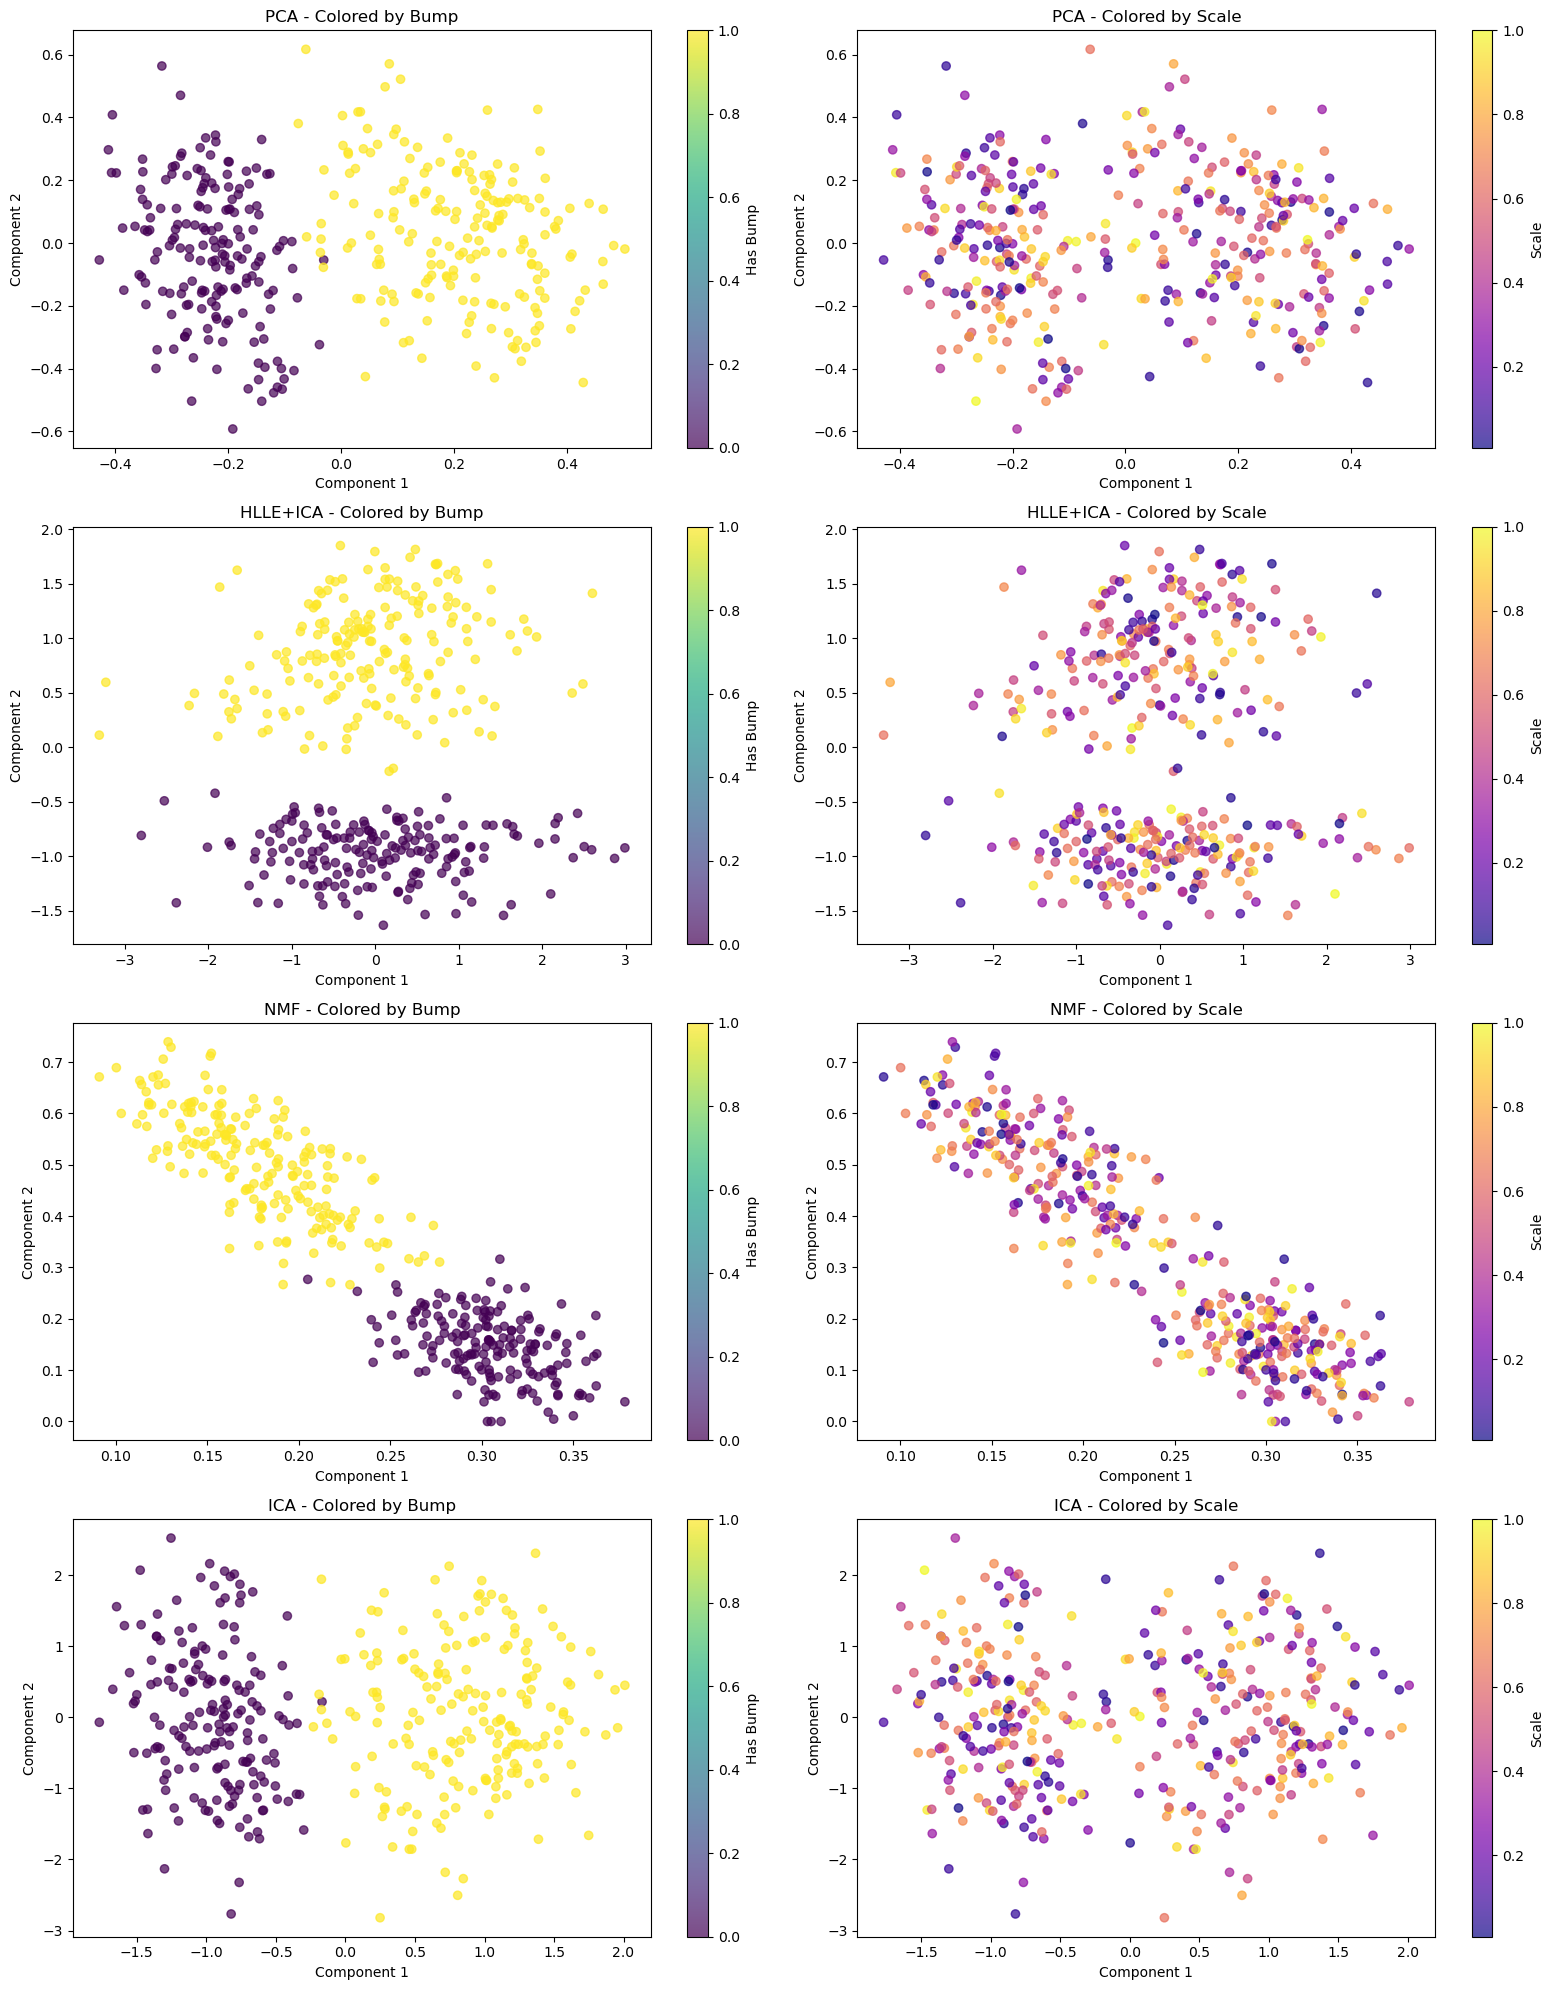

In [ ]:
# 4. Visualize results
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Plot each technique with bump and scale coloring
techniques = ["PCA", "HLLE+ICA", "NMF", "ICA"]
for i, technique in enumerate(techniques):
    # Skip if the method failed
    if np.all(results[technique] == 0):
        continue
        
    # Plot colored by bump
    scatter = axes[i, 0].scatter(results[technique][:, 0], results[technique][:, 1], 
                                c=has_bump, cmap='viridis', alpha=0.7)
    axes[i, 0].set_title(f"{technique} - Colored by Bump")
    axes[i, 0].set_xlabel("Component 1")
    axes[i, 0].set_ylabel("Component 2")
    
    plt.colorbar(scatter, ax=axes[i, 0], label="Has Bump")

    
    # Plot colored by scale
    scatter = axes[i, 1].scatter(results[technique][:, 0], results[technique][:, 1], 
                                c=scales, cmap='plasma', alpha=0.7)
    axes[i, 1].set_title(f"{technique} - Colored by Scale")
    axes[i, 1].set_xlabel("Component 1")
    axes[i, 1].set_ylabel("Component 2")
    plt.colorbar(scatter, ax=axes[i, 1], label="Scale")

plt.tight_layout()
plt.savefig("latent_space_analysis.png", dpi=300)
plt.show()


In [ ]:
# 5. Correlation Analysis
print("\nCorrelation Analysis:")
for technique in techniques:
    # Skip if the method failed
    if np.all(results[technique] == 0):
        continue
        
    bump_corr_1 = np.corrcoef(results[technique][:, 0], has_bump)[0, 1]
    bump_corr_2 = np.corrcoef(results[technique][:, 1], has_bump)[0, 1]
    scale_corr_1 = np.corrcoef(results[technique][:, 0], scales)[0, 1]
    scale_corr_2 = np.corrcoef(results[technique][:, 1], scales)[0, 1]
    
    print(f"\n{technique} Analysis:")
    print(f"Component 1 correlation with bump: {bump_corr_1:.4f}")
    print(f"Component 2 correlation with bump: {bump_corr_2:.4f}")
    print(f"Component 1 correlation with scale: {scale_corr_1:.4f}")
    print(f"Component 2 correlation with scale: {scale_corr_2:.4f}")




Correlation Analysis:

PCA Analysis:
Component 1 correlation with bump: 0.8973
Component 2 correlation with bump: 0.1444
Component 1 correlation with scale: -0.0074
Component 2 correlation with scale: -0.0395

HLLE+ICA Analysis:
Component 1 correlation with bump: -0.0553
Component 2 correlation with bump: 0.9249
Component 1 correlation with scale: 0.0249
Component 2 correlation with scale: -0.0111

NMF Analysis:
Component 1 correlation with bump: -0.8769
Component 2 correlation with bump: 0.8979
Component 1 correlation with scale: -0.0225
Component 2 correlation with scale: -0.0107

ICA Analysis:
Component 1 correlation with bump: 0.9087
Component 2 correlation with bump: 0.0173
Component 1 correlation with scale: -0.0143
Component 2 correlation with scale: 0.0376


In [12]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-1.352, Skew=0.152, Negent=0.056
component_1: Kurt=-0.301, Skew=-0.056, Negent=0.044
component_2: Kurt=-0.194, Skew=0.116, Negent=0.042
component_3: Kurt=-0.480, Skew=-0.044, Negent=0.042

HLLE+ICA Quality Metrics:
component_0: Kurt=0.600, Skew=0.078, Negent=0.372
component_1: Kurt=-1.504, Skew=0.136, Negent=0.507

NMF Quality Metrics:
component_0: Kurt=-1.284, Skew=-0.084, Negent=0.005
component_1: Kurt=-1.358, Skew=0.157, Negent=0.030

ICA Quality Metrics:
component_0: Kurt=-1.405, Skew=0.118, Negent=0.495
component_1: Kurt=-0.342, Skew=0.014, Negent=0.405


Projecting individual latent vectors onto learned components...
Projection shapes:
PCA: (369, 4)
ICA: (369, 2)
HLLE+ICA: (369, 2)


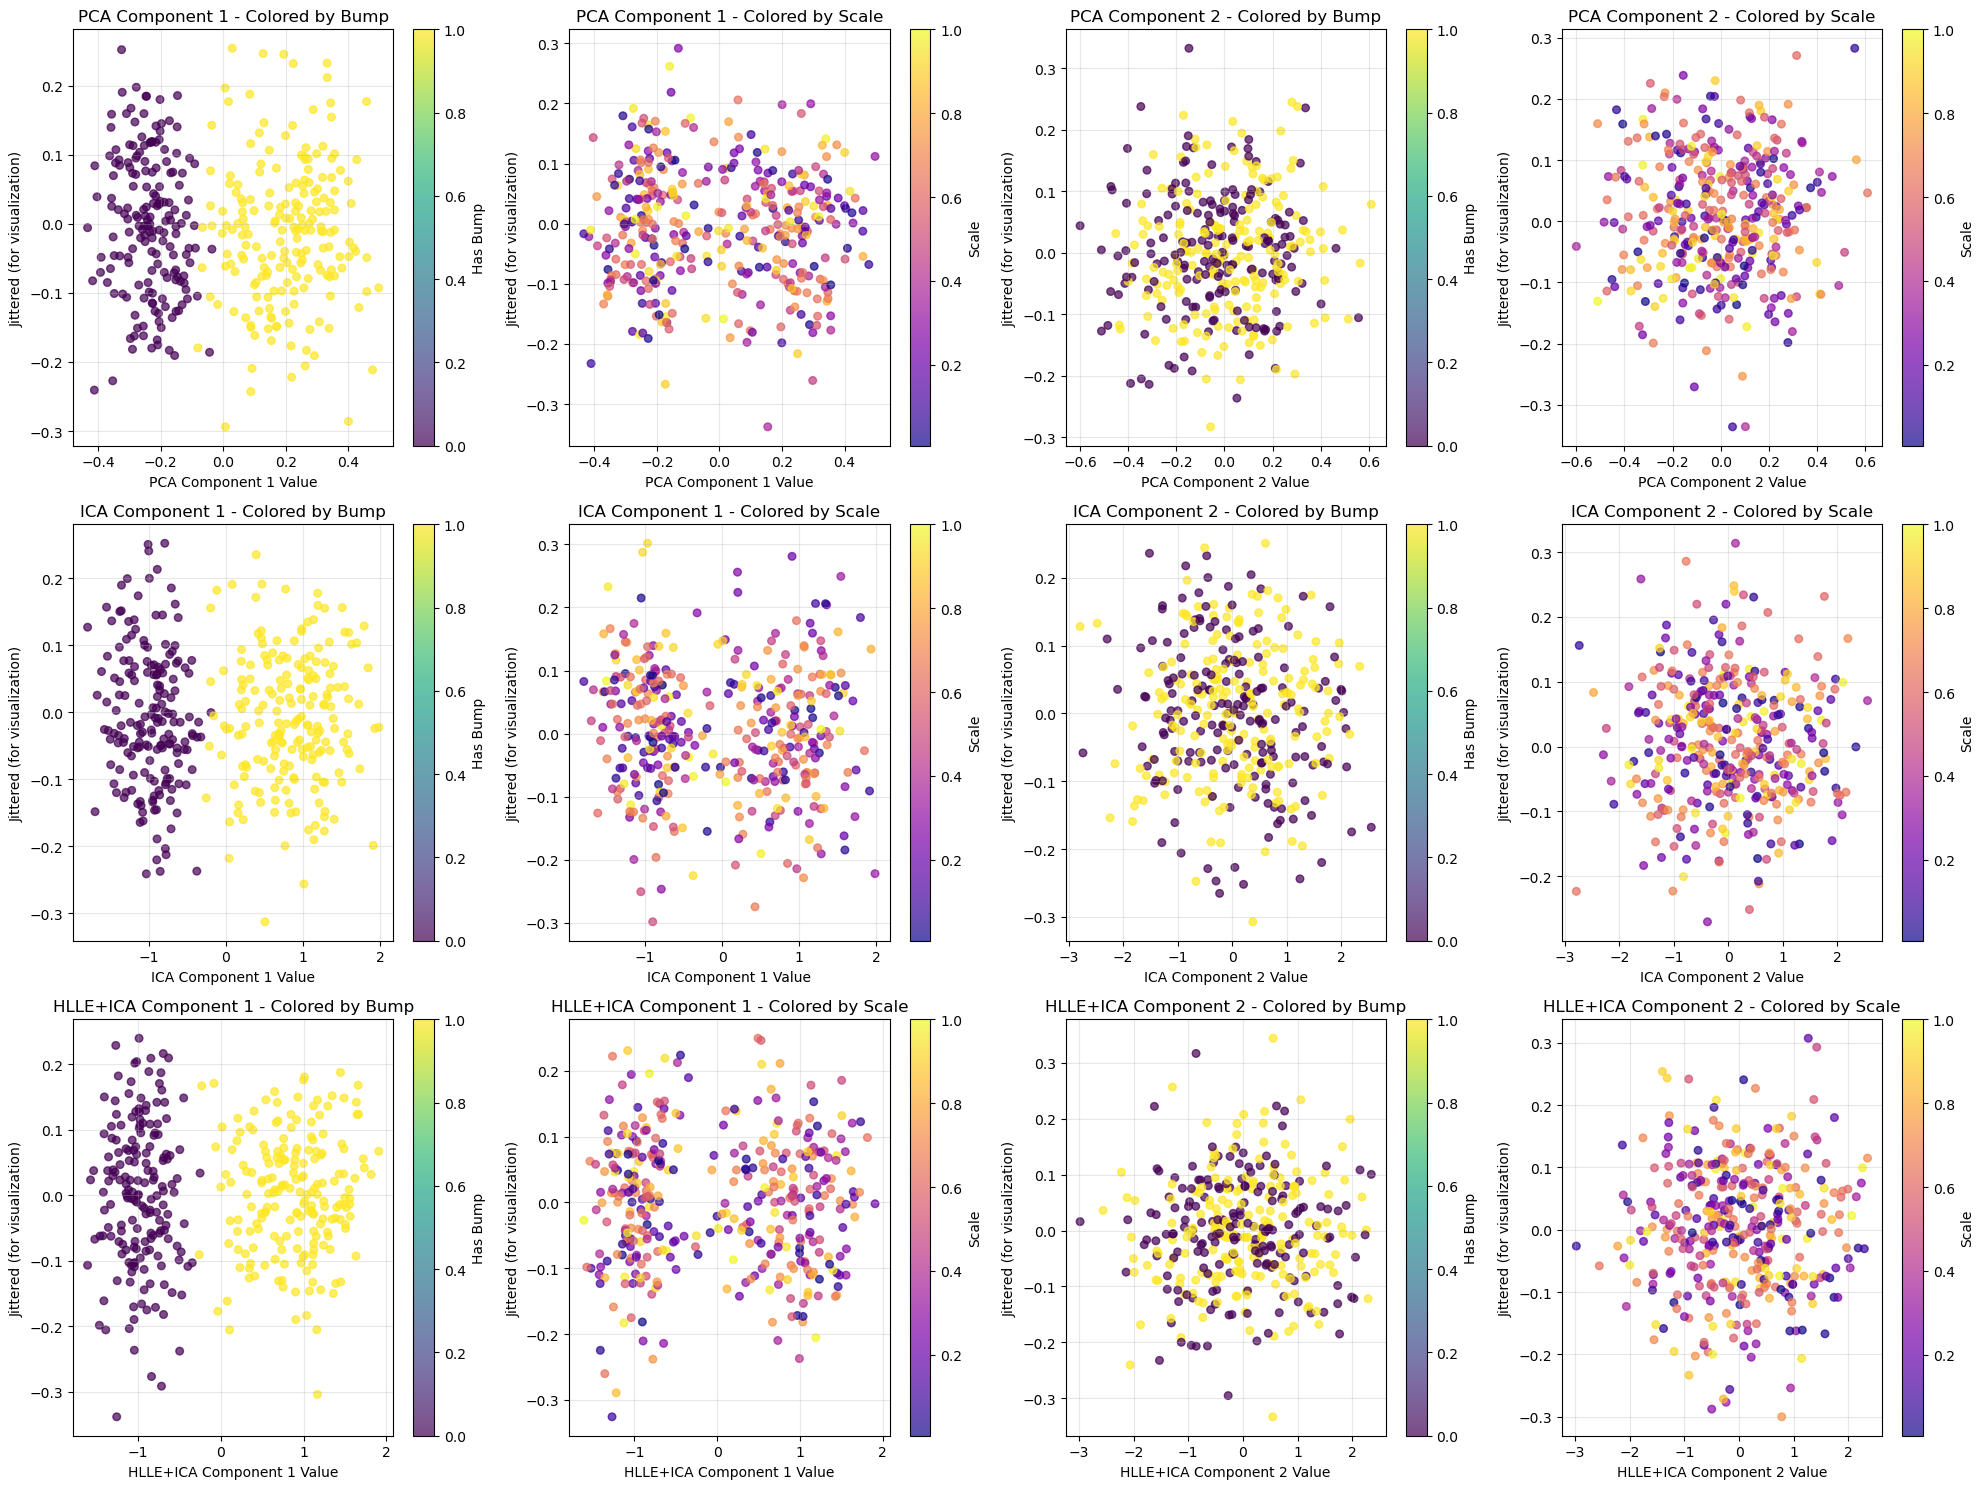

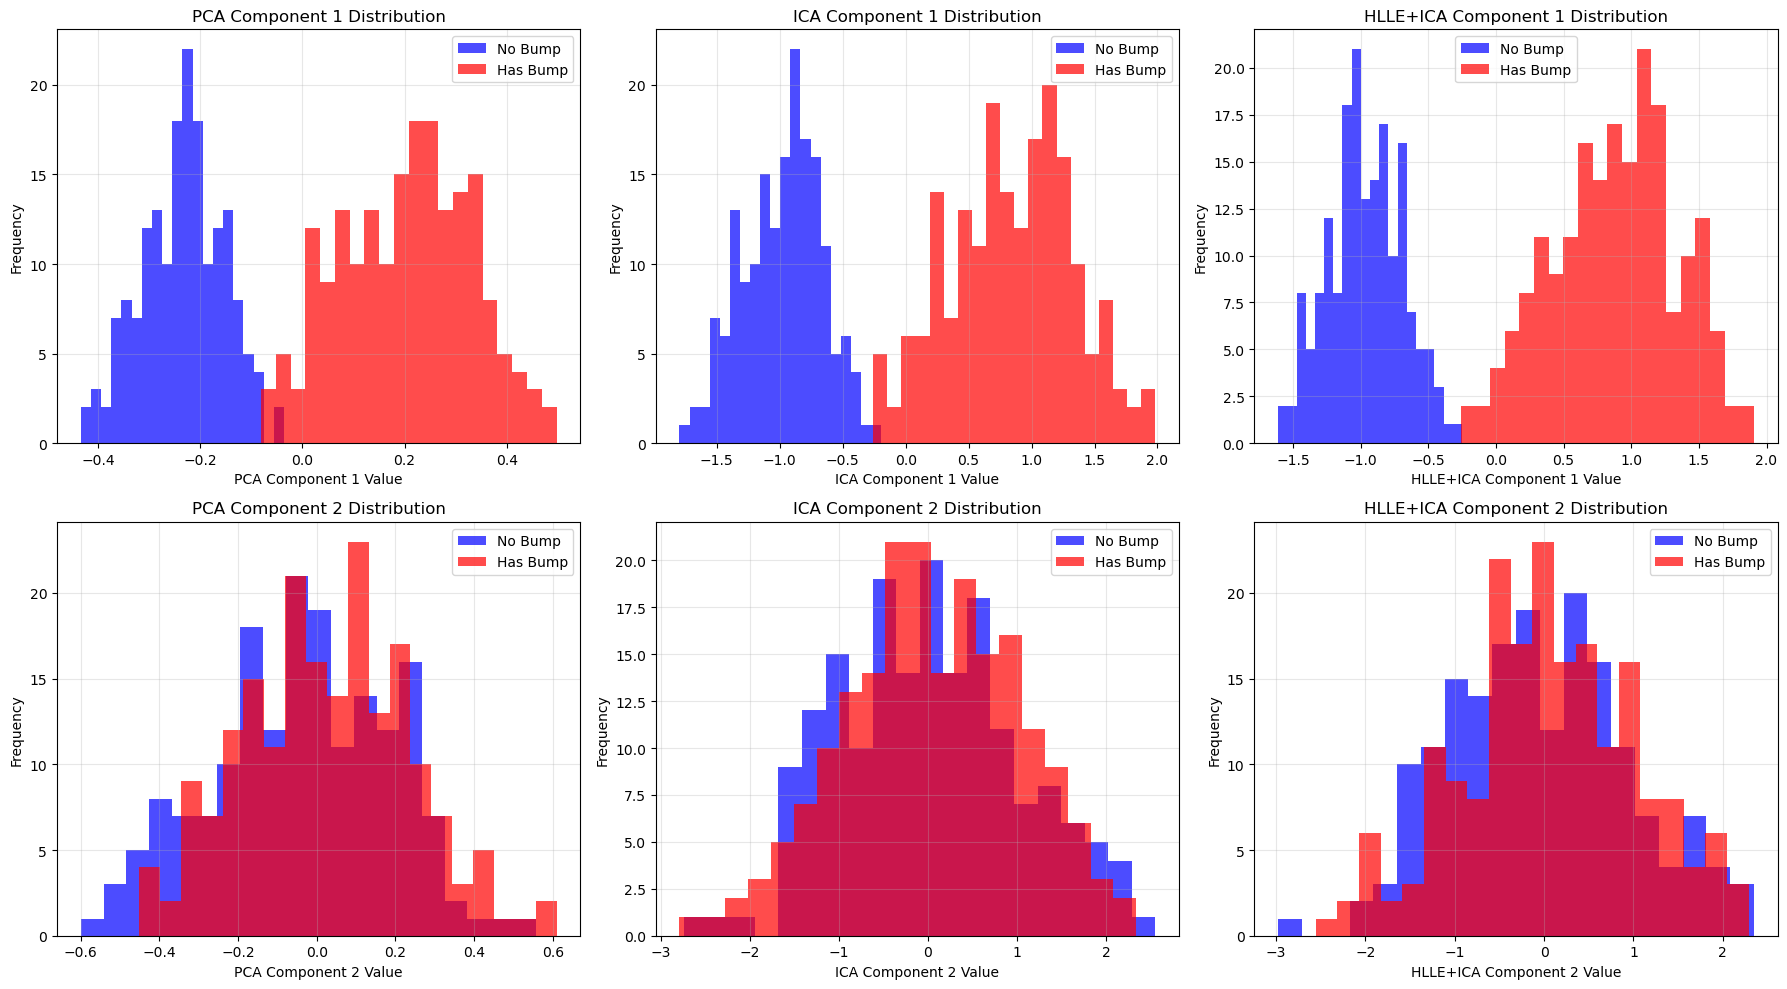

In [ ]:
# 9. Project individual latent vectors onto learned components
print("Projecting individual latent vectors onto learned components...")

# Use the already fitted transformers from your previous analysis
X_16d = latent_vectors.cpu().numpy()

# Dictionary to store projections
individual_projections = {}

# 9.1. Project onto PCA components (using the already fitted PCA)
# Get the PCA transformation matrix (components)
pca_components = pca.components_  # Shape: (n_components, n_features)
pca_projections = X_16d @ pca_components.T  # Shape: (n_samples, n_components)
individual_projections["PCA"] = pca_projections

# 9.2. Project onto ICA components (using the already fitted ICA)
# For ICA, we need to use the unmixing matrix
ica_components = ica.components_  # Shape: (n_components, n_features)  
ica_projections = X_16d @ ica_components.T  # Shape: (n_samples, n_components)
individual_projections["ICA"] = ica_projections

# 9.3. For HLLE+ICA, recreate the transformations with best parameters
if best_Y_hlle_ica is not None:
    # Get the best parameters
    best_n_neighbors = best_params[0]
    
    # Recreate HLLE transformation
    hlle_for_projection = LocallyLinearEmbedding(n_neighbors=best_n_neighbors,
                                                 n_components=2,
                                                 method='hessian',
                                                 eigen_solver='dense')
    hlle_for_projection.fit(X)
    
    # Apply HLLE to all 16D vectors
    hlle_transformed = hlle_for_projection.transform(X_16d)
    
    # Recreate ICA transformation that was applied to HLLE results
    ica_after_hlle = FastICA(n_components=2, random_state=42)
    # Fit on the original HLLE-transformed training data
    hlle_train_transformed = hlle_for_projection.transform(X)
    ica_after_hlle.fit(hlle_train_transformed)
    
    # Apply ICA to the HLLE-transformed data
    hlle_ica_projections = ica_after_hlle.transform(hlle_transformed)
    individual_projections["HLLE+ICA"] = hlle_ica_projections
else:
    individual_projections["HLLE+ICA"] = None

print("Projection shapes:")
for method, proj in individual_projections.items():
    if proj is not None:
        print(f"{method}: {proj.shape}")

# 10. Visualize projections of first two components against labels
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

methods = ["PCA", "ICA", "HLLE+ICA"]
for i, method in enumerate(methods):
    if individual_projections[method] is None:
        for j in range(4):
            axes[i, j].text(0.5, 0.5, f"{method}\nFailed", ha='center', va='center')
        continue
    
    projections = individual_projections[method]
    
    # Component 1 - show scalar values with jitter, colored by bump
    jittered_y1 = np.random.normal(0, 0.1, len(projections))  # Random jitter for y-axis
    scatter1 = axes[i, 0].scatter(projections[:, 0], jittered_y1, c=has_bump, 
                                 cmap='viridis', alpha=0.7, s=30)
    axes[i, 0].set_xlabel(f"{method} Component 1 Value")
    axes[i, 0].set_ylabel("Jittered (for visualization)")
    axes[i, 0].set_title(f"{method} Component 1 - Colored by Bump")
    axes[i, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[i, 0], label="Has Bump")
    
    # Component 1 - show scalar values with jitter, colored by scale
    jittered_y2 = np.random.normal(0, 0.1, len(projections))  # Random jitter for y-axis
    scatter2 = axes[i, 1].scatter(projections[:, 0], jittered_y2, c=scales, 
                                 cmap='plasma', alpha=0.7, s=30)
    axes[i, 1].set_xlabel(f"{method} Component 1 Value")
    axes[i, 1].set_ylabel("Jittered (for visualization)")
    axes[i, 1].set_title(f"{method} Component 1 - Colored by Scale")
    axes[i, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[i, 1], label="Scale")
    
    # Component 2 - show scalar values with jitter, colored by bump
    if projections.shape[1] > 1:
        jittered_y3 = np.random.normal(0, 0.1, len(projections))
        scatter3 = axes[i, 2].scatter(projections[:, 1], jittered_y3, c=has_bump, 
                                     cmap='viridis', alpha=0.7, s=30)
        axes[i, 2].set_xlabel(f"{method} Component 2 Value")
        axes[i, 2].set_ylabel("Jittered (for visualization)")
        axes[i, 2].set_title(f"{method} Component 2 - Colored by Bump")
        axes[i, 2].grid(True, alpha=0.3)
        plt.colorbar(scatter3, ax=axes[i, 2], label="Has Bump")
        
        # Component 2 - show scalar values with jitter, colored by scale
        jittered_y4 = np.random.normal(0, 0.1, len(projections))
        scatter4 = axes[i, 3].scatter(projections[:, 1], jittered_y4, c=scales, 
                                     cmap='plasma', alpha=0.7, s=30)
        axes[i, 3].set_xlabel(f"{method} Component 2 Value")
        axes[i, 3].set_ylabel("Jittered (for visualization)")
        axes[i, 3].set_title(f"{method} Component 2 - Colored by Scale")
        axes[i, 3].grid(True, alpha=0.3)
        plt.colorbar(scatter4, ax=axes[i, 3], label="Scale")
    else:
        axes[i, 2].text(0.5, 0.5, f"Only 1\nComponent", ha='center', va='center')
        axes[i, 3].text(0.5, 0.5, f"Only 1\nComponent", ha='center', va='center')

plt.tight_layout()
plt.savefig("component_projections_vs_labels_both_components.png", dpi=300, bbox_inches='tight')
plt.show()

# 13. Enhanced histogram visualization - both components (unchanged)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, method in enumerate(methods):
    if individual_projections[method] is None:
        axes[0, i].text(0.5, 0.5, f"{method}\nFailed", ha='center', va='center')
        axes[1, i].text(0.5, 0.5, f"{method}\nFailed", ha='center', va='center')
        continue
    
    projections = individual_projections[method]
    bump_mask = has_bump == 1
    no_bump_mask = has_bump == 0
    
    # Component 1 histograms (top row)
    first_component = projections[:, 0]
    axes[0, i].hist(first_component[no_bump_mask], alpha=0.7, label='No Bump', 
                   bins=20, color='blue')
    axes[0, i].hist(first_component[bump_mask], alpha=0.7, label='Has Bump', 
                   bins=20, color='red')
    axes[0, i].set_xlabel(f"{method} Component 1 Value")
    axes[0, i].set_ylabel("Frequency")
    axes[0, i].set_title(f"{method} Component 1 Distribution")
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # Component 2 histograms (bottom row)
    if projections.shape[1] > 1:
        second_component = projections[:, 1]
        axes[1, i].hist(second_component[no_bump_mask], alpha=0.7, label='No Bump', 
                       bins=20, color='blue')
        axes[1, i].hist(second_component[bump_mask], alpha=0.7, label='Has Bump', 
                       bins=20, color='red')
        axes[1, i].set_xlabel(f"{method} Component 2 Value")
        axes[1, i].set_ylabel("Frequency")
        axes[1, i].set_title(f"{method} Component 2 Distribution")
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    else:
        axes[1, i].text(0.5, 0.5, f"Only 1\nComponent", ha='center', va='center')

plt.tight_layout()
plt.savefig("component_distributions_both_components.png", dpi=300, bbox_inches='tight')
plt.show()

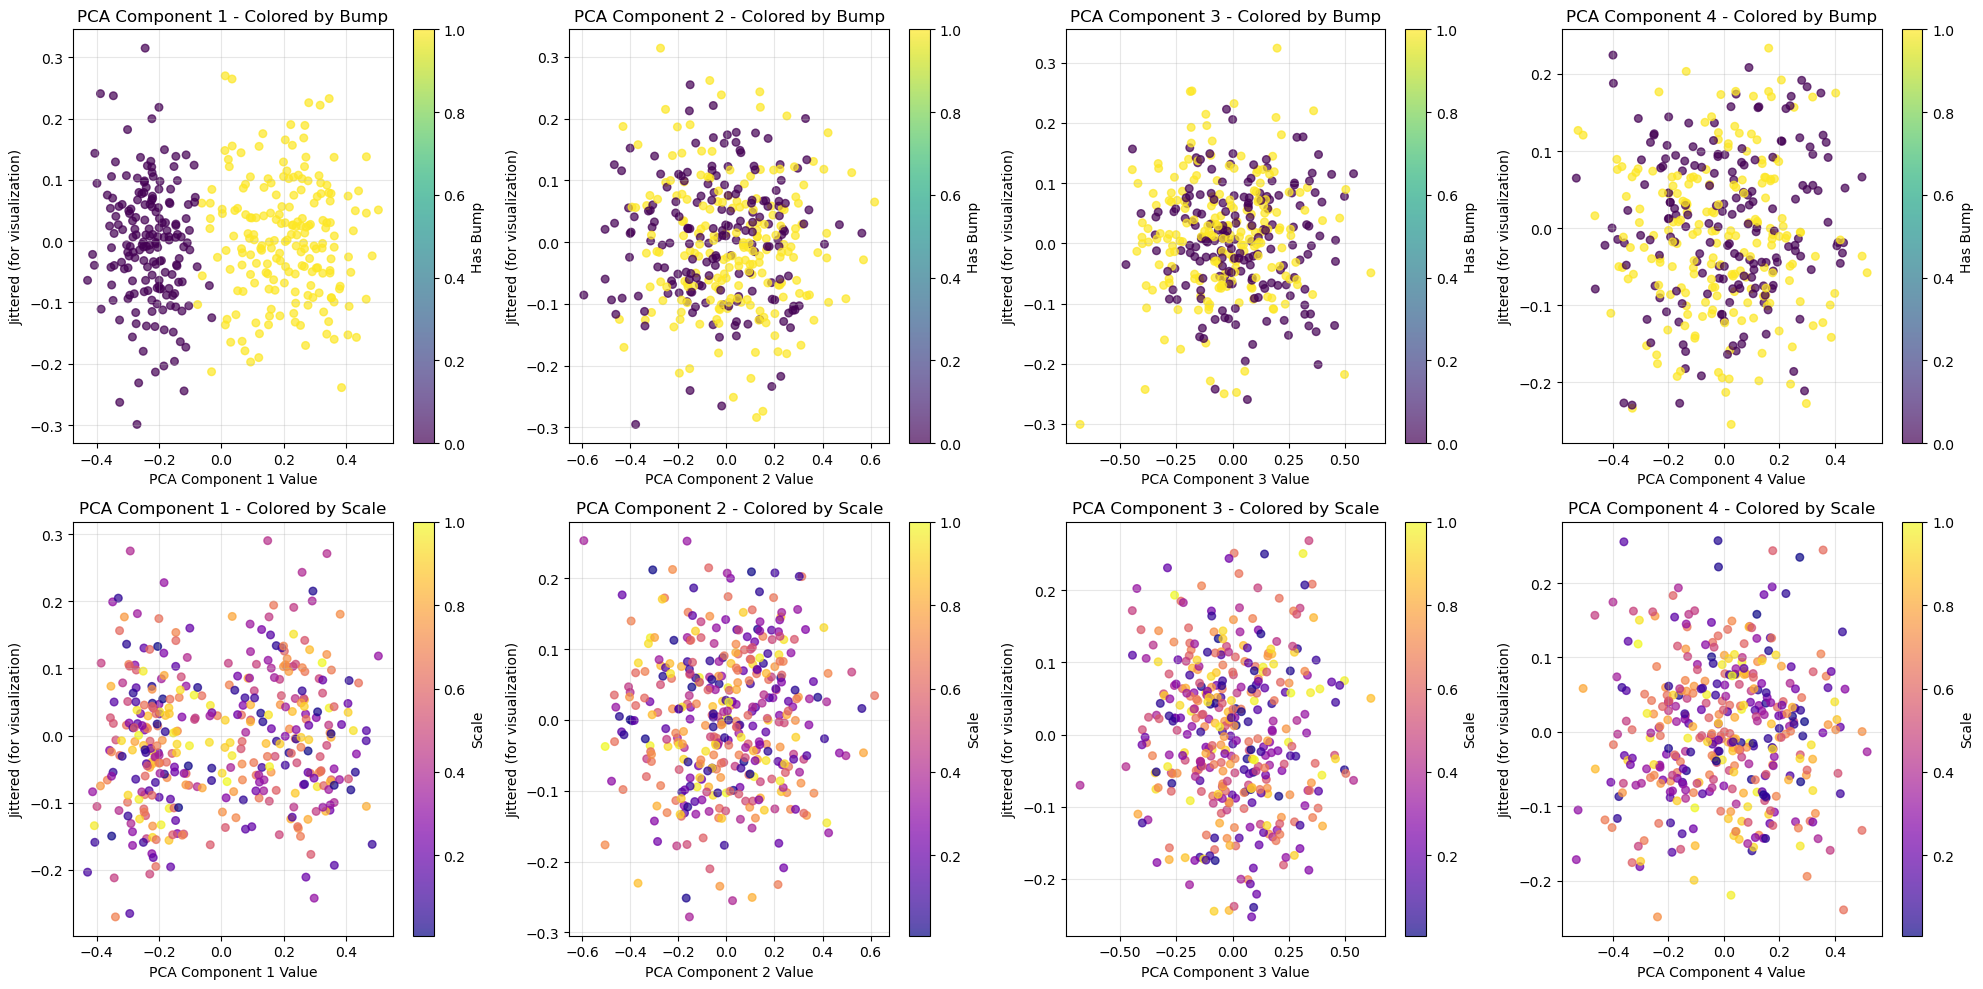

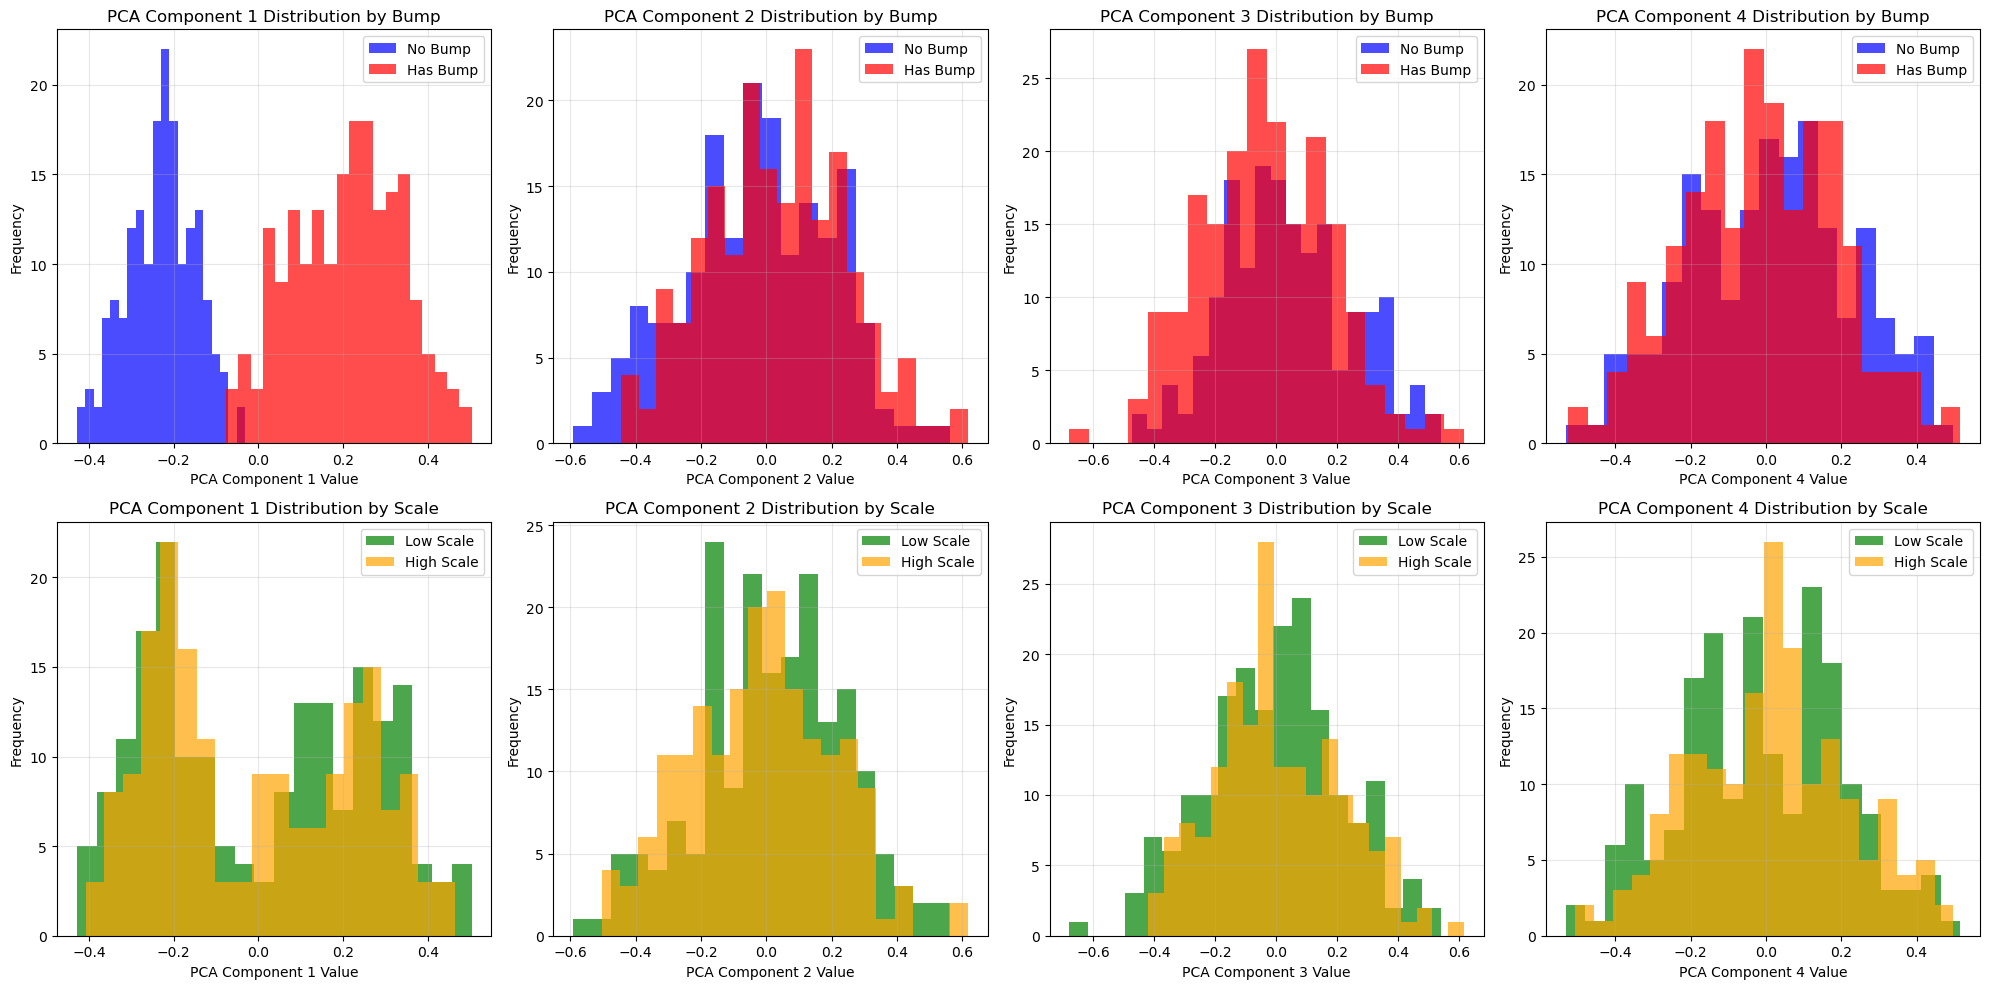


Detailed PCA Correlation Analysis:
PCA Component 1:
  Correlation with bump: 0.8973
  Correlation with scale: -0.0074
PCA Component 2:
  Correlation with bump: 0.1444
  Correlation with scale: -0.0395
PCA Component 3:
  Correlation with bump: -0.1751
  Correlation with scale: 0.0110
PCA Component 4:
  Correlation with bump: -0.0588
  Correlation with scale: -0.0105


In [ ]:
# Plot all 4 PCA components for bump and scale
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Get PCA results
pca_results = results["PCA"]

# Top row: All 4 components colored by bump
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[0, i].scatter(pca_results[:, i], jittered_y, c=has_bump, 
                                cmap='viridis', alpha=0.7, s=30)
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Jittered (for visualization)")
    axes[0, i].set_title(f"PCA Component {i+1} - Colored by Bump")
    axes[0, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, i], label="Has Bump")

# Bottom row: All 4 components colored by scale
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[1, i].scatter(pca_results[:, i], jittered_y, c=scales, 
                                cmap='plasma', alpha=0.7, s=30)
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Jittered (for visualization)")
    axes[1, i].set_title(f"PCA Component {i+1} - Colored by Scale")
    axes[1, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, i], label="Scale")

plt.tight_layout()
plt.savefig("pca_all_components_vs_labels.png", dpi=300, bbox_inches='tight')
plt.show()

# Also create histogram distributions for all 4 PCA components
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

bump_mask = has_bump == 1
no_bump_mask = has_bump == 0

# Top row: Component distributions by bump
for i in range(4):
    component = pca_results[:, i]
    axes[0, i].hist(component[no_bump_mask], alpha=0.7, label='No Bump', 
                   bins=20, color='blue')
    axes[0, i].hist(component[bump_mask], alpha=0.7, label='Has Bump', 
                   bins=20, color='red')
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Frequency")
    axes[0, i].set_title(f"PCA Component {i+1} Distribution by Bump")
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Bottom row: Component distributions by scale (split into high/low scale)
scale_median = np.median(scales)
high_scale_mask = scales > scale_median
low_scale_mask = scales <= scale_median

for i in range(4):
    component = pca_results[:, i]
    axes[1, i].hist(component[low_scale_mask], alpha=0.7, label='Low Scale', 
                   bins=20, color='green')
    axes[1, i].hist(component[high_scale_mask], alpha=0.7, label='High Scale', 
                   bins=20, color='orange')
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Frequency")
    axes[1, i].set_title(f"PCA Component {i+1} Distribution by Scale")
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_all_components_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# Print correlation analysis for all 4 PCA components
print("\nDetailed PCA Correlation Analysis:")
for i in range(4):
    bump_corr = np.corrcoef(pca_results[:, i], has_bump)[0, 1]
    scale_corr = np.corrcoef(pca_results[:, i], scales)[0, 1]
    print(f"PCA Component {i+1}:")
    print(f"  Correlation with bump: {bump_corr:.4f}")
    print(f"  Correlation with scale: {scale_corr:.4f}")


Analyzing scale encoding across all 16 dimensions:
Latent dim 1: scale correlation = -0.1027
Latent dim 2: scale correlation = 0.0045
Latent dim 3: scale correlation = -0.1122
Latent dim 4: scale correlation = 0.0299
Latent dim 5: scale correlation = -0.0935
Latent dim 6: scale correlation = 0.0301
Latent dim 7: scale correlation = -0.0065
Latent dim 8: scale correlation = -0.0578
Latent dim 9: scale correlation = 0.0111
Latent dim 10: scale correlation = 0.0555
Latent dim 11: scale correlation = -0.0134
Latent dim 12: scale correlation = 0.0592
Latent dim 13: scale correlation = 0.0398
Latent dim 14: scale correlation = -0.0427
Latent dim 15: scale correlation = -0.0789
Latent dim 16: scale correlation = -0.0595

Linear regression R² for predicting scale from all 16 dimensions: 0.0600
This suggests scale information is poorly encoded in the full latent space


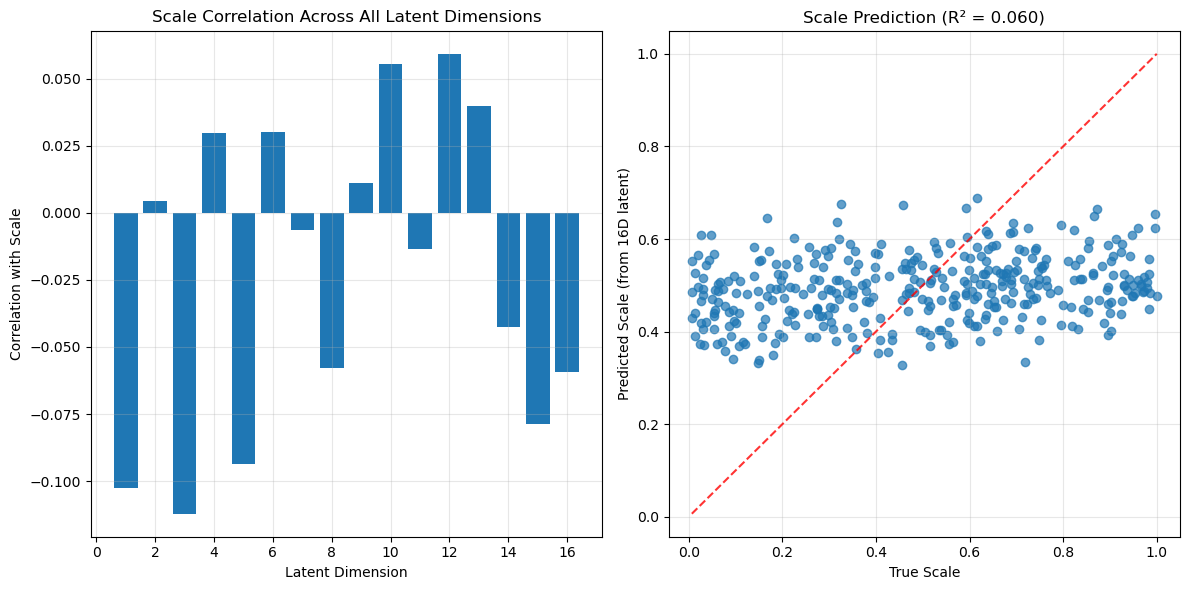

In [21]:
# Test if scale information is distributed across all dimensions
print("\nAnalyzing scale encoding across all 16 dimensions:")

# Calculate correlation of each individual latent dimension with scale
latent_scale_correlations = []
for dim in range(X.shape[1]):
    corr = np.corrcoef(X[:, dim], scales)[0, 1]
    latent_scale_correlations.append(corr)
    print(f"Latent dim {dim+1}: scale correlation = {corr:.4f}")

# Check if scale can be predicted using all 16 dimensions
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Train a linear model to predict scale from all 16 latent dimensions
lr = LinearRegression()
lr.fit(X, scales)
predicted_scales = lr.predict(X)
r2 = r2_score(scales, predicted_scales)

print(f"\nLinear regression R² for predicting scale from all 16 dimensions: {r2:.4f}")
print(f"This suggests scale information is {'well' if r2 > 0.7 else 'poorly'} encoded in the full latent space")

# Visualize the correlation pattern
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, 17), latent_scale_correlations)
plt.xlabel('Latent Dimension')
plt.ylabel('Correlation with Scale')
plt.title('Scale Correlation Across All Latent Dimensions')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(scales, predicted_scales, alpha=0.7)
plt.xlabel('True Scale')
plt.ylabel('Predicted Scale (from 16D latent)')
plt.title(f'Scale Prediction (R² = {r2:.3f})')
plt.plot([scales.min(), scales.max()], [scales.min(), scales.max()], 'r--', alpha=0.8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scale_analysis_full_latent_space.png", dpi=300, bbox_inches='tight')
plt.show()